# True Parameters at 1 PA Model

```python
m1 = 1e6
m2 = 10
a = 0.8 
e0 = 0.4 
xI0 = 1.0
dist = 0.4

qS = xp.pi/4
phiS = 1.0
qK = 1
phiK = xp.pi/3

Phi_phi0 = 0.9
Phi_theta0 = 0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p = 0.0
dev_0_e = 0.0
dev_1_p = 0.0
dev_1_e = 0.0
dev_2_p = 0.0
dev_2_e = 0.0

evolve_1PA = True
evolve_primary = False
evolve_2PA = False
deviation_included = True

p0 = 7.5

best_fit = [ 1.38157246e+01 , 1.00042793e+01 , 8.00138681e-01 , 7.49924060e+00,3.99933604e-01 , 7.85947492e-01,  9.99634868e-01,  9.66081240e-01, 3.41367413e-01, -2.40188581e-04, -6.24286978e-05]

# logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

In [5]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

In [6]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [38]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [ 1.38157246e+01 , 1.00042793e+01 , 8.00138681e-01 , 7.49924060e+00,3.99933604e-01 ,
             7.85947492e-01,  9.99634868e-01,  9.66081240e-01, 3.41367413e-01, -2.40188581e-04, -6.24286978e-05]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.4
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 1.0

chi2 = 0.0

dev_0_p=best_fit[9]
dev_0_e=best_fit[10]
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [8]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000214.0649443562), 10.0042793, 0.800138681, 7.4992406, 0.399933604, 1.0, 0.4, 0.785947492, 0.999634868, 1, 1.0471975511965976, 0.96608124, 0.5, 0.341367413, 0.0, False, False, False, True, -0.000240188581, -6.24286978e-05, 0.0, 0.0, 0.0, 0.0)
SNR:  136.8833822982727


Body is not plunging, Fisher should be stable.
waveform shape:  (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000214.0649443562), 10.0042793, 0.800138681, 7.4992406, 0.399933604, 1.0, 0.4, 0.785947492, 0.999634868, 1, 1.0471975511965976, 0.96608124, 0.5, 0.341367413, 0.0, False, False, False, True, -0.000240188581, -6.24286978e-05, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 136.8833822982727
calculating stable deltas...
Gamma_ii for m1: 22260.760609820158
Gamma_ii for m1: 22260.76060945666
Gamma_ii for m1: 22260.76060948037
Gamma_ii for m1: 22260.760610138215
Gamma_ii for m1: 22260.760609642097
Gamma_ii for m1: 22260.760608574747
Gamma_ii for m1: 22260.76061255539
Gamma_ii for m1: 22260.76061850792
Gamma_ii for m1: 22260.7606121401
Gamma_ii for m1: 22260.760623241138
Gamma_ii for m1: 22260.760687707076
Gamma_ii for m1: 22260.760990773677
Gamma_ii for m1: 22260.760618147397
Gamma_ii for m1: 22260.760700585055
Gamma_ii for m1: 22260.763955306913
Gamma_ii for m1: 

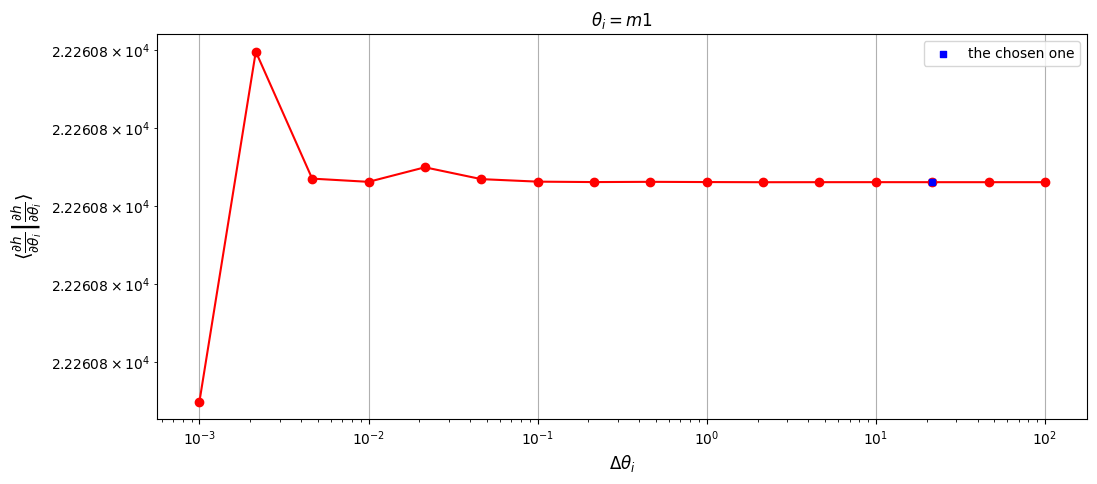

Gamma_ii for m2: 14188645022963.383
Gamma_ii for m2: 14188645022163.34
Gamma_ii for m2: 14188645023154.629
Gamma_ii for m2: 14188645022919.904
Gamma_ii for m2: 14188645023134.475
Gamma_ii for m2: 14188645020107.064
Gamma_ii for m2: 14188645018545.752
Gamma_ii for m2: 14188645005190.914
Gamma_ii for m2: 14188645128539.203
Gamma_ii for m2: 14188645012704.092
Gamma_ii for m2: 14188645275461.678
Gamma_ii for m2: 14188645099980.928
Gamma_ii for m2: 14188646881410.148
Gamma_ii for m2: 14188643139085.908
Gamma_ii for m2: 14188648102002.123
Gamma_ii for m2: 14188647161297.354
[np.float64(5.638614310952841e-11), np.float64(6.986495615911899e-11), np.float64(1.6543130721491238e-11), np.float64(1.5122678180343843e-11), np.float64(2.1336851770974506e-10), np.float64(1.1003957727881932e-10), np.float64(9.41234197186492e-10), np.float64(8.693450850666202e-09), np.float64(8.163930468653609e-09), np.float64(1.8518863558589477e-08), np.float64(1.2367689005078848e-08), np.float64(1.2555314369245028e-07)

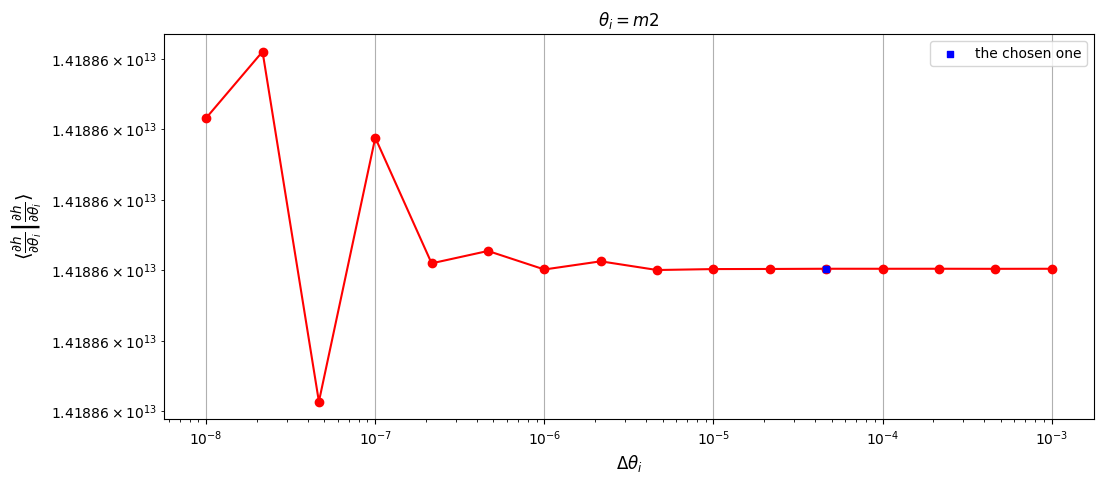

Gamma_ii for a: 1817404421784763.5
Gamma_ii for a: 1817404320501787.2
Gamma_ii for a: 1817404393802694.5
Gamma_ii for a: 1817404736280905.0
Gamma_ii for a: 1817403466665543.8
Gamma_ii for a: 1817401347699686.2
Gamma_ii for a: 1817395049370092.0
Gamma_ii for a: 1817405652772450.5
Gamma_ii for a: 1817433379870458.0
Gamma_ii for a: 1817408575722917.8
Gamma_ii for a: 1817428217936719.0
Gamma_ii for a: 1817708823985638.5
Gamma_ii for a: 1816982629618858.0
Gamma_ii for a: 1817069639097230.5
Gamma_ii for a: 1814161874375601.8
Gamma_ii for a: 1819607223049634.5
[np.float64(5.572946818022071e-08), np.float64(4.033274459991092e-08), np.float64(1.8844355561702755e-07), np.float64(6.985875093434313e-07), np.float64(1.1659317080302647e-06), np.float64(3.46558091287472e-06), np.float64(5.8343619336302385e-06), np.float64(1.5256183976040055e-05), np.float64(1.3648085450671738e-05), np.float64(1.0807697166465984e-05), np.float64(0.00015437348667550786), np.float64(0.00039967050589406636), np.float64(4

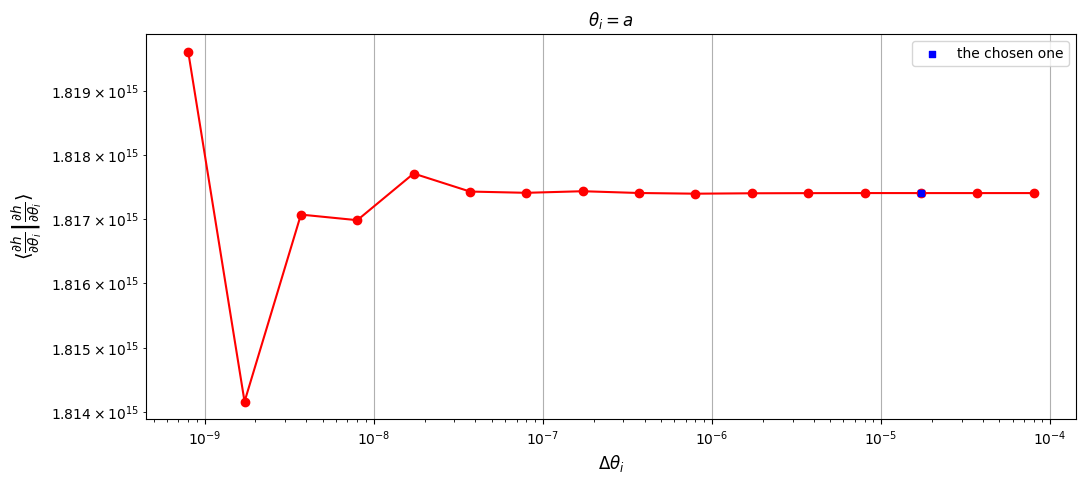

Gamma_ii for p0: 1174027391915628.0
Gamma_ii for p0: 1174027389792262.2
Gamma_ii for p0: 1174027416328505.0
Gamma_ii for p0: 1174027443960094.2
Gamma_ii for p0: 1174027437127990.5
Gamma_ii for p0: 1174027189617547.0
Gamma_ii for p0: 1174027696615898.2
Gamma_ii for p0: 1174029009622628.5
Gamma_ii for p0: 1174028348741715.8
Gamma_ii for p0: 1174023047436281.8
Gamma_ii for p0: 1174036076297910.0
Gamma_ii for p0: 1174030401197339.0
Gamma_ii for p0: 1174058784835292.5
Gamma_ii for p0: 1173866469362801.8
Gamma_ii for p0: 1173781537481857.5
Gamma_ii for p0: 1173604535825016.0
[np.float64(1.8086168759450476e-09), np.float64(2.2602745371130995e-08), np.float64(2.3535726862394547e-08), np.float64(5.819373154270819e-09), np.float64(2.108217302706843e-07), np.float64(4.318453071519594e-07), np.float64(1.118376734721439e-06), np.float64(5.629173379487046e-07), np.float64(4.5155037165381714e-06), np.float64(1.1097496824232124e-05), np.float64(4.833861682978762e-06), np.float64(2.417565314455861e-05)

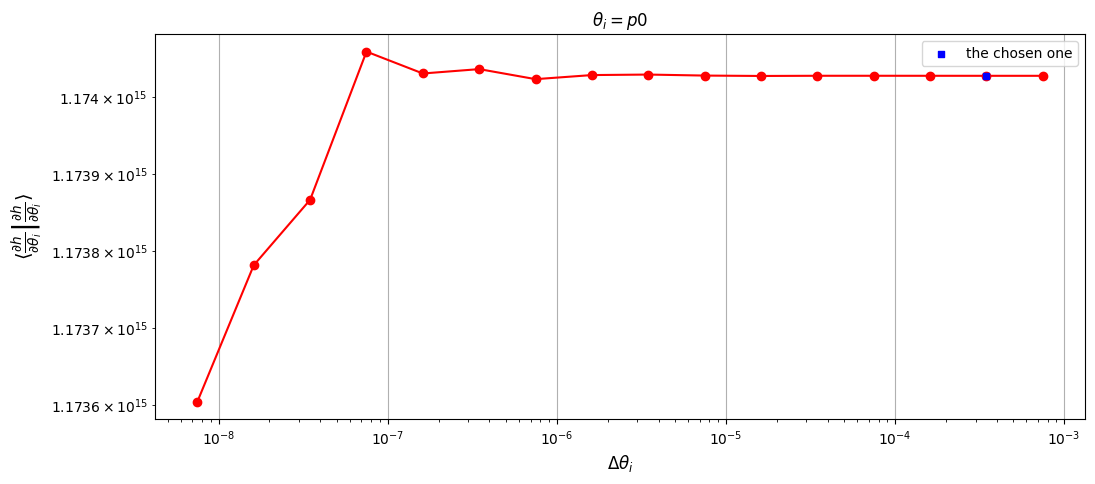

Gamma_ii for e0: 3818532055182674.5
Gamma_ii for e0: 3818531832866138.0
Gamma_ii for e0: 3818530445307738.0
Gamma_ii for e0: 3818531493264425.5
Gamma_ii for e0: 3818535871893164.0
Gamma_ii for e0: 3818521522466227.0
Gamma_ii for e0: 3818531786294908.0
Gamma_ii for e0: 3818504324603437.0
Gamma_ii for e0: 3818392892147441.0
Gamma_ii for e0: 3818562598911831.0
Gamma_ii for e0: 3818828488904343.0
Gamma_ii for e0: 3817903681752648.0
Gamma_ii for e0: 3816953252505134.5
Gamma_ii for e0: 3819886071395192.0
Gamma_ii for e0: 3810899585391918.0
Gamma_ii for e0: 3840742974274603.0
[np.float64(5.8220422463555116e-08), np.float64(3.6337497366429294e-07), np.float64(2.744397131065985e-07), np.float64(1.1466773877206374e-06), np.float64(3.7578489089495275e-06), np.float64(2.687899238612575e-06), np.float64(7.191740308910604e-06), np.float64(2.9183077578308362e-05), np.float64(4.444257753908788e-05), np.float64(6.962606288408786e-05), np.float64(0.00024222904210890352), np.float64(0.0002490020664753272

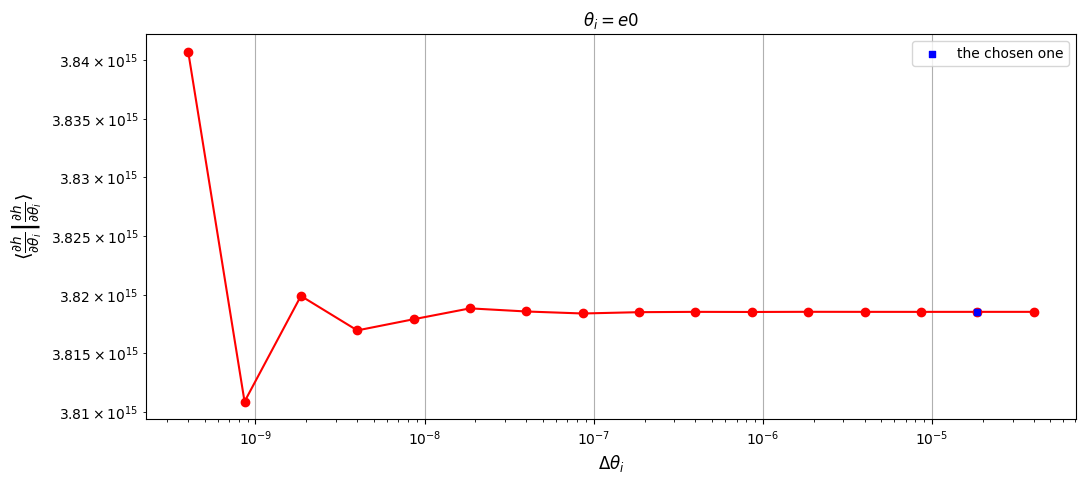

Gamma_ii for qS: 58813.45318883948
Gamma_ii for qS: 58813.45328574292
Gamma_ii for qS: 58813.45328595566
Gamma_ii for qS: 58813.45328595664
Gamma_ii for qS: 58813.453285956464
Gamma_ii for qS: 58813.45328595895
Gamma_ii for qS: 58813.453285957905
Gamma_ii for qS: 58813.45328594197
Gamma_ii for qS: 58813.4532859662
Gamma_ii for qS: 58813.45328598807
Gamma_ii for qS: 58813.4532859246
Gamma_ii for qS: 58813.45328581922
Gamma_ii for qS: 58813.45328625638
Gamma_ii for qS: 58813.45328713661
Gamma_ii for qS: 58813.45328686523
Gamma_ii for qS: 58813.453284729476
[np.float64(1.6476407877265486e-09), np.float64(3.617105217222381e-12), np.float64(1.6701183539401235e-14), np.float64(2.969099295893562e-15), np.float64(4.2309664966481466e-14), np.float64(1.7814595775360934e-14), np.float64(2.709303107503543e-13), np.float64(4.119625273051635e-13), np.float64(3.7187968681046877e-13), np.float64(1.079143881587232e-12), np.float64(1.791851425075946e-12), np.float64(7.433016374760965e-12), np.float64(1.

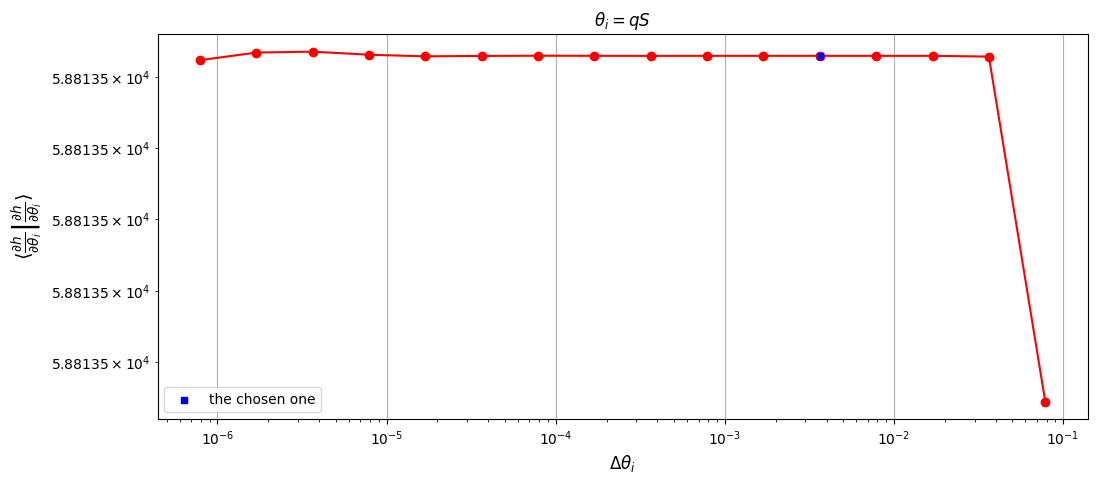

Gamma_ii for phiS: 1114712.7346773907
Gamma_ii for phiS: 1114712.7346405047
Gamma_ii for phiS: 1114712.7346404232
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.734640423
Gamma_ii for phiS: 1114712.7346404227
Gamma_ii for phiS: 1114712.7346404234
Gamma_ii for phiS: 1114712.7346404244
Gamma_ii for phiS: 1114712.7346404248
Gamma_ii for phiS: 1114712.7346404337
Gamma_ii for phiS: 1114712.7346404374
Gamma_ii for phiS: 1114712.7346404179
Gamma_ii for phiS: 1114712.7346403843
[np.float64(3.3090105409189914e-11), np.float64(7.310468674706683e-14), np.float64(2.0887053356304813e-16), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(2.0887053356304818e-16), np.float64(6.266116006891441e-16), np.float64(8.354821342521914e-16), np.float64(4.1774106712609557e-16), np.float64(7.937080275395753e-15), np.float64(3.3419285370087267e-15), np.float

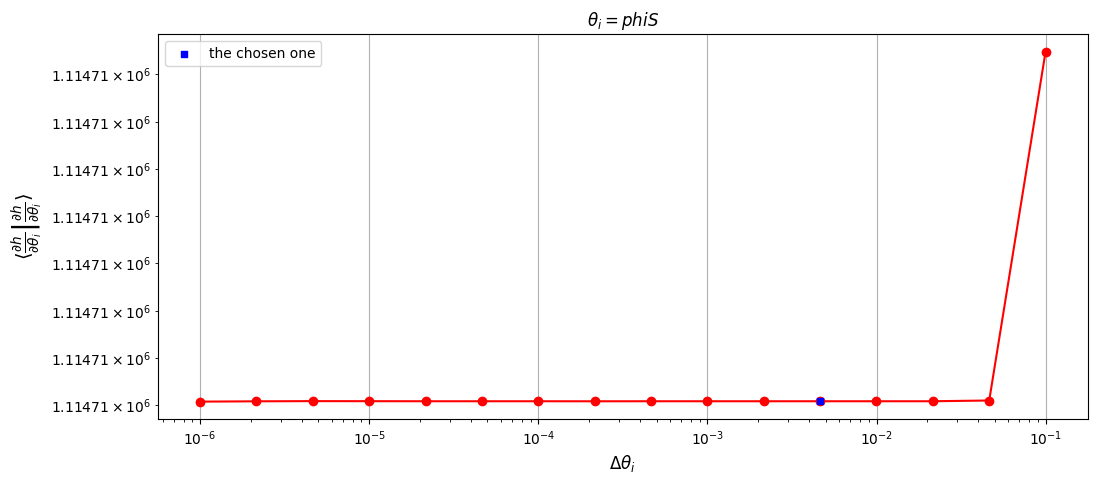

Gamma_ii for dev0p: 1161709945637358.5
Gamma_ii for dev0p: 1161710066899326.2
Gamma_ii for dev0p: 1161709346964758.2
Gamma_ii for dev0p: 1161709179215319.2
Gamma_ii for dev0p: 1161712441424544.5
Gamma_ii for dev0p: 1161693699257695.0
Gamma_ii for dev0p: 1161714576391930.0
Gamma_ii for dev0p: 1161717667977933.5
Gamma_ii for dev0p: 1161770883544472.2
Gamma_ii for dev0p: 1161491219994563.0
Gamma_ii for dev0p: 1161280140541242.5
Gamma_ii for dev0p: 1160451562213620.5
Gamma_ii for dev0p: 1159695040908038.2
Gamma_ii for dev0p: 1163477543340550.5
Gamma_ii for dev0p: 1159807708639955.0
Gamma_ii for dev0p: 1176849218886086.0
[np.float64(1.0438229916837637e-07), np.float64(6.197200443303656e-07), np.float64(1.4439882373427313e-07), np.float64(2.8081038895044724e-06), np.float64(1.6133484120191034e-05), np.float64(1.7970966930483482e-05), np.float64(2.6612197513369694e-06), np.float64(4.580556053909137e-05), np.float64(0.00024077973651024165), np.float64(0.00018176445626816743), np.float64(0.0007

/home/svu/e1583490/scratch/packages_for_multi_inference/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


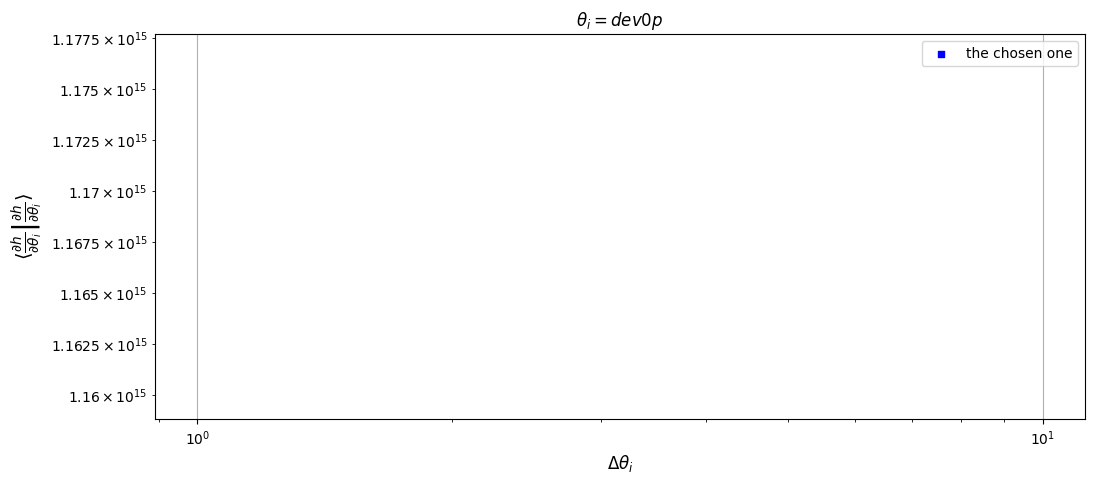

Gamma_ii for dev0e: 14332420246962.438
Gamma_ii for dev0e: 14332406454368.521
Gamma_ii for dev0e: 14332023739855.584
Gamma_ii for dev0e: 14332996826263.426
Gamma_ii for dev0e: 14332322458790.543
Gamma_ii for dev0e: 14332961173769.203
Gamma_ii for dev0e: 14339290768670.008
Gamma_ii for dev0e: 14300638533936.584
Gamma_ii for dev0e: 14395616704831.617
Gamma_ii for dev0e: 14334960308864.959
Gamma_ii for dev0e: 14520473549886.418
Gamma_ii for dev0e: 14319891126061.39
Gamma_ii for dev0e: 13827153030676.03
Gamma_ii for dev0e: 16207628126379.2
Gamma_ii for dev0e: 9943429785033.293
Gamma_ii for dev0e: 11489602040679.803
[np.float64(9.623362245501792e-07), np.float64(2.6703452344501657e-05), np.float64(6.789134328549753e-05), np.float64(4.705221186739334e-05), np.float64(4.456266719183406e-05), np.float64(0.00044141617621941615), np.float64(0.0027028327890184006), np.float64(0.006597714626783275), np.float64(0.004231361277585635), np.float64(0.012775977338763178), np.float64(0.014007258997938797

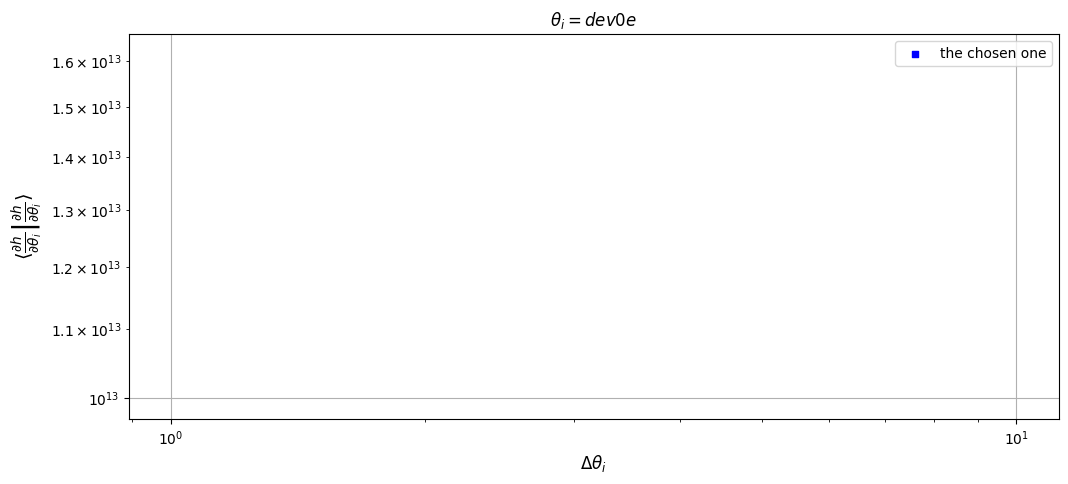

stable deltas: {'m1': 21.548958789739252, 'm2': 4.643575108722344e-05, 'a': 1.7238465311827528e-05, 'p0': 0.0003480839142953559, 'e0': 1.856327350512915e-05, 'qS': 0.0036480451026731702, 'phiS': 0.004639894040998785, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'dev0p': -1.1148566355308984e-05, 'dev0e': -2.8976834660546715e-06}
Time taken to compute stable deltas is 333.6962294578552 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 22.638355255126953 seconds


In [9]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','dev0p','dev0e']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [39]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4,0,0])

In [40]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8,9,10
0,2.227029e+16,-5.496675e+14,5.995615e+15,5.103966e+15,8.889203e+15,-2.936886e+10,1.338533e+11,-3.500754e+10,-1.305964e+10,-4.938772e+15,-5.617559e+14
1,-5.496675e+14,1.418865e+13,-1.581679e+14,-1.274258e+14,-2.065845e+14,6.585040e+08,-3.000374e+09,7.846553e+08,2.312032e+08,1.283217e+14,1.366418e+13
2,5.995615e+15,-1.581679e+14,1.817404e+15,1.403546e+15,2.191018e+15,-7.156298e+09,3.260934e+10,-8.527752e+09,-1.691669e+09,-1.435551e+15,-1.472353e+14
3,5.103966e+15,-1.274258e+14,1.403546e+15,1.174027e+15,2.008306e+15,-6.624994e+09,3.019361e+10,-7.896625e+09,-2.719655e+09,-1.146956e+15,-1.281957e+14
4,8.889203e+15,-2.065845e+14,2.191018e+15,2.008306e+15,3.818532e+15,-1.324027e+10,6.036457e+10,-1.578867e+10,-7.197294e+09,-1.839692e+15,-2.276029e+14
5,-2.936886e+10,6.585040e+08,-7.156298e+09,-6.624994e+09,-1.324027e+10,5.881345e+04,-2.436458e+05,6.373546e+04,2.942287e+04,5.846529e+09,7.431316e+08
6,1.338533e+11,-3.000374e+09,3.260934e+10,3.019361e+10,6.036457e+10,-2.436458e+05,1.114713e+06,-2.907384e+05,-1.341996e+05,-2.663786e+10,-3.386968e+09
7,-3.500754e+10,7.846553e+08,-8.527752e+09,-7.896625e+09,-1.578867e+10,6.373546e+04,-2.907384e+05,7.606102e+04,3.510004e+04,6.966252e+09,8.858151e+08
8,-1.305964e+10,2.312032e+08,-1.691669e+09,-2.719655e+09,-7.197294e+09,2.942287e+04,-1.341996e+05,3.510004e+04,3.663958e+04,1.972798e+09,3.408714e+08
9,-4.938772e+15,1.283217e+14,-1.435551e+15,-1.146956e+15,-1.839692e+15,5.846529e+09,-2.663786e+10,6.966252e+09,1.972798e+09,1.161710e+15,1.224052e+14


In [41]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):

    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                ax.axis("off")
                continue
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D - 1 and j == 0:
                    # ellipse handles (match levels dynamically)
                    level_labels = {f"{int(p*100)}%" for p in levels}
                    for item in ax.get_lines():
                        if item.get_label() in level_labels:
                            legend_handles.append(item)
                
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


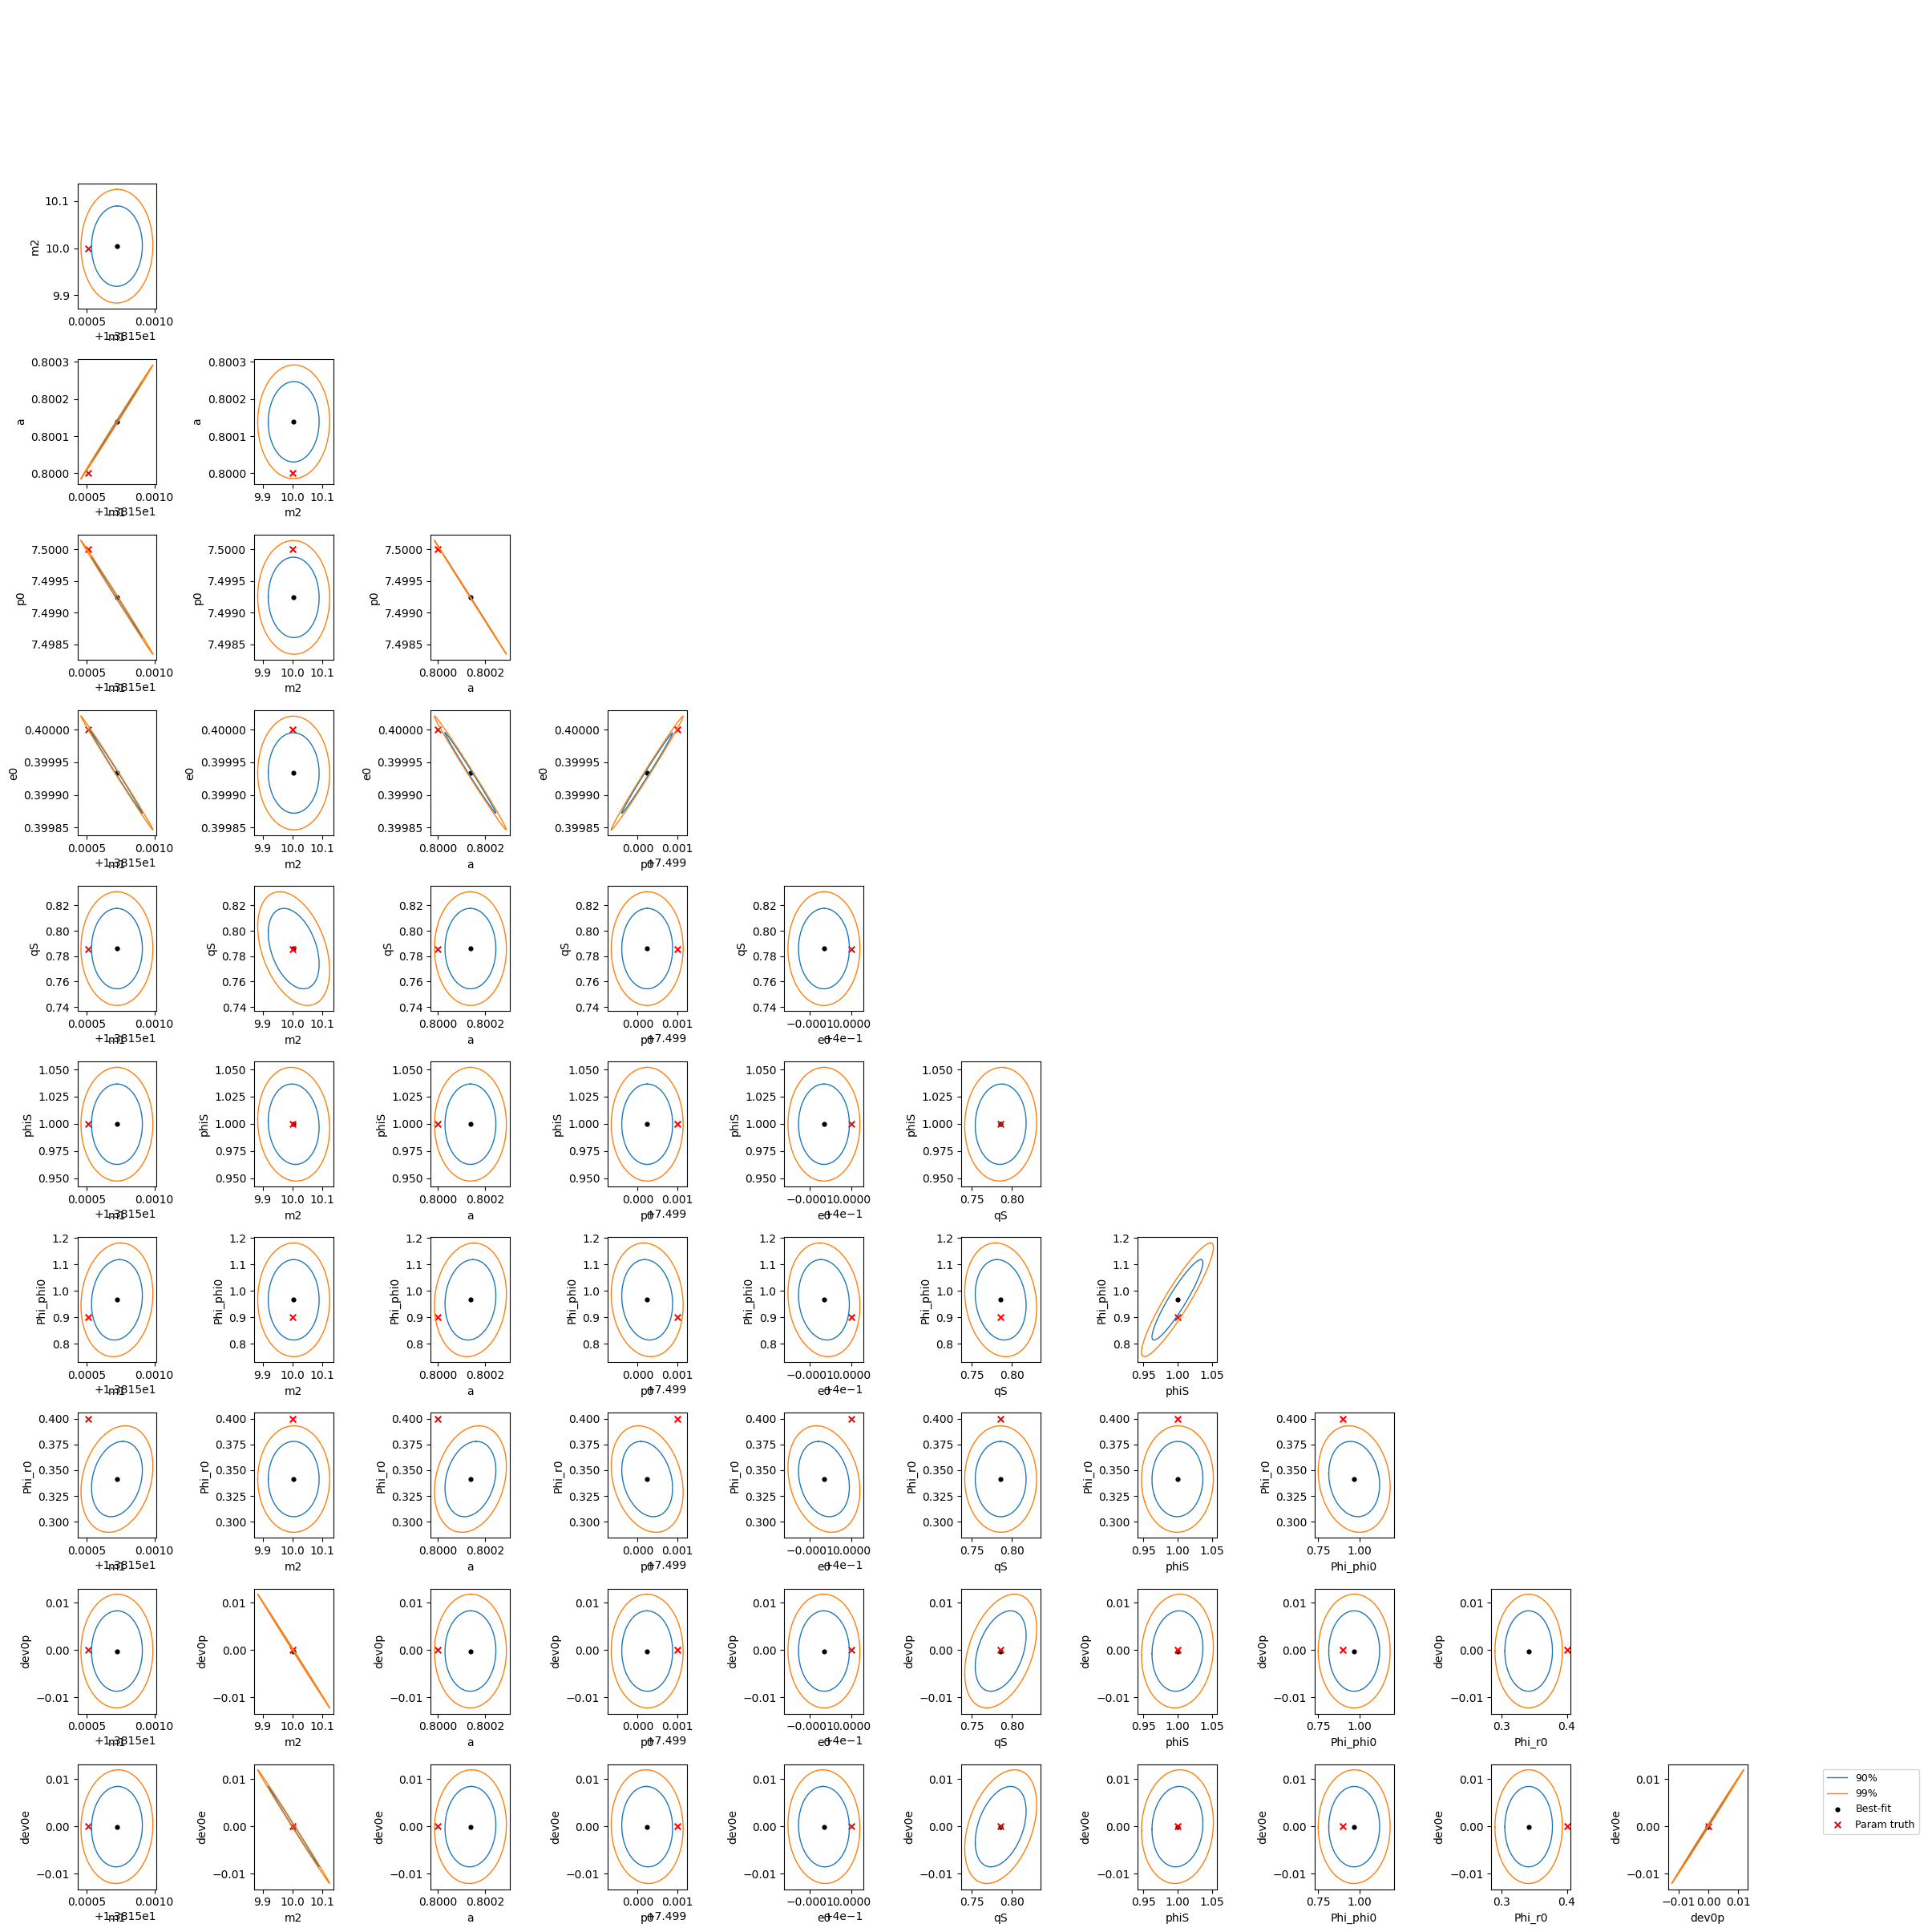

In [42]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.90, 0.99])


In [43]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 10
a_true = 0.8 
e0_true = 0.4 
xI0_true = 1.0
dist_true = 0.4
qS_true = xp.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = xp.pi/3
Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.5
chi2 = 0.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])




In [44]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [45]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [46]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  7.406738026385176
separatrix p:  3.3636344376256564


# P evolution is done considering true waveform (1PA)

[0.0, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


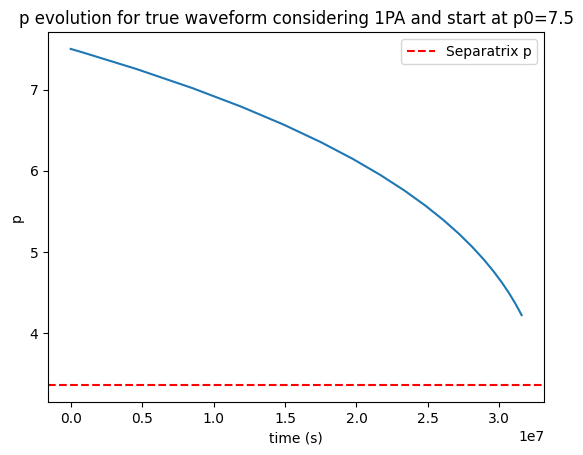

In [47]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.5')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

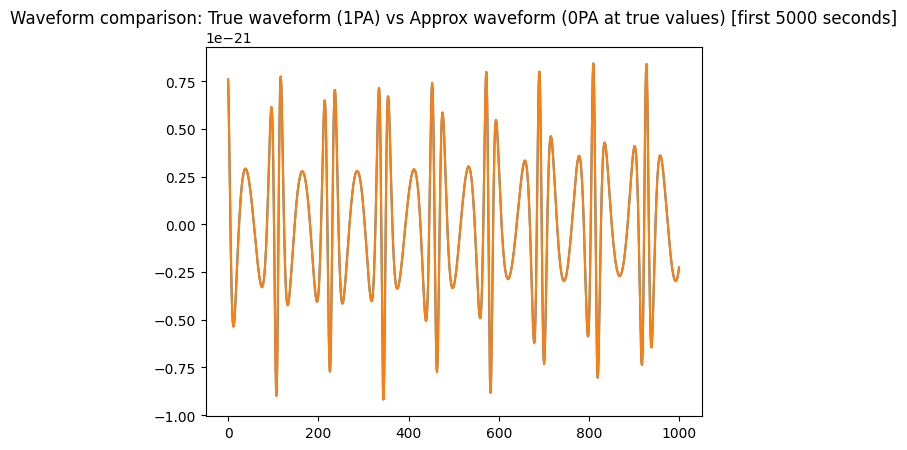

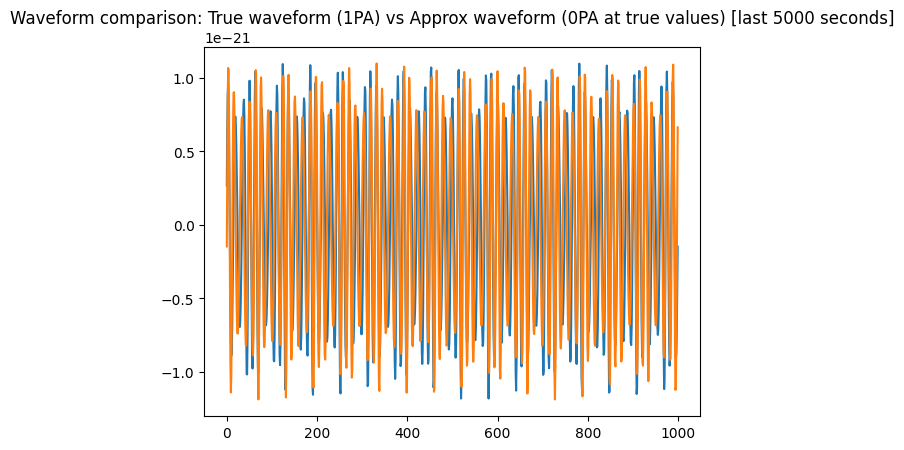

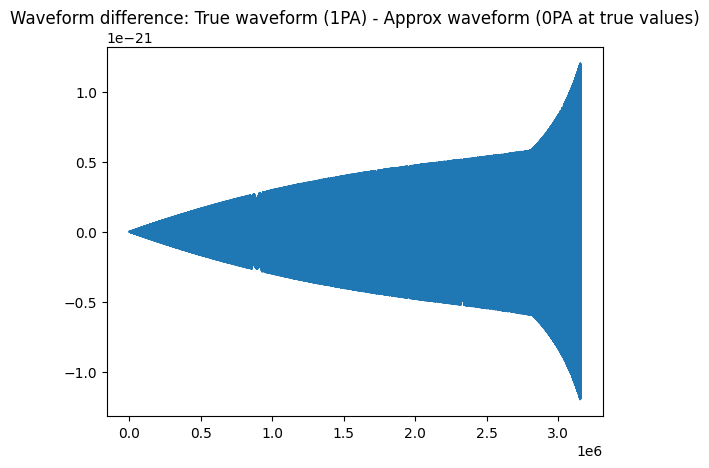

In [48]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

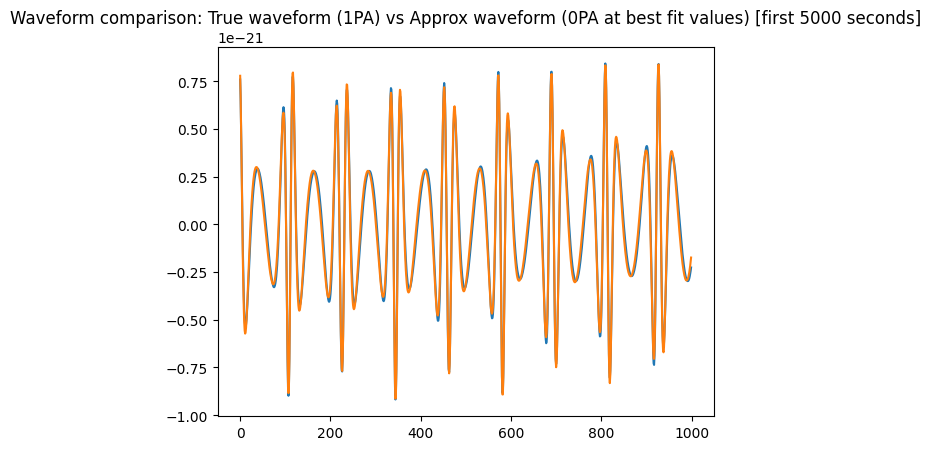

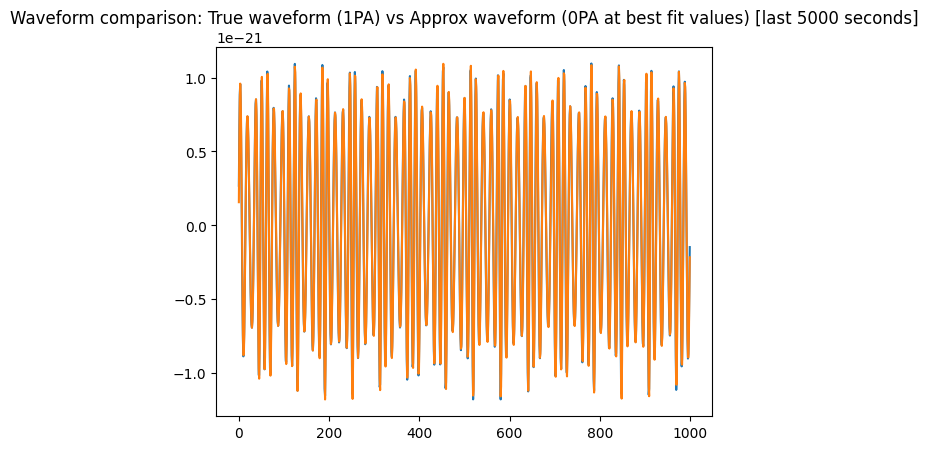

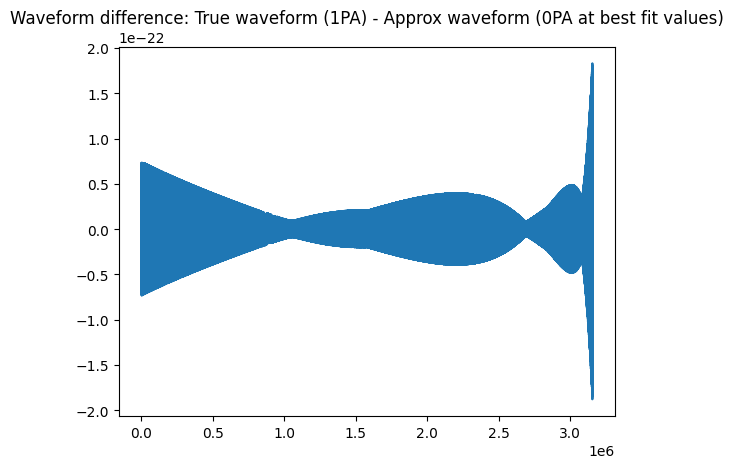

In [49]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

# Overlap and mismatch

In [50]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9994592495269523
mismatch between best fit point and true waveform: 0.0005407504730476909
overlap between approximate waveform and true waveform (both at true points) 0.9005241196983437
mismatch between approximate waveform and true waveform (both at true points): 0.09947588030165633


# table true vs bias

In [51]:
best_fit


[13.8157246,
 10.0042793,
 0.800138681,
 7.4992406,
 0.399933604,
 0.785947492,
 0.999634868,
 0.96608124,
 0.341367413,
 -0.000240188581,
 -6.24286978e-05]

In [53]:
import pandas as pd
best_fit_ = best_fit.copy()
best_fit_[0] = np.exp(best_fit[0])
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true,dev_0_p_true,dev_0_e_true]
df = pd.DataFrame({'Best Fit': best_fit_, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.000214e+06  1000000.000000
m2        1.000428e+01       10.000000
a         8.001387e-01        0.800000
p0        7.499241e+00        7.500000
e0        3.999336e-01        0.400000
qS        7.859475e-01        0.785398
phiS      9.996349e-01        1.000000
Phi_phi0  9.660812e-01        0.900000
Phi_r0    3.413674e-01        0.400000
dev0p    -2.401886e-04        0.000000
dev0e    -6.242870e-05        0.000000


In [35]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)
